# Data Profiler Assignment

This notebook completes **Part B (Data Acquisition)**, **Part C (Data Understanding & Cleaning)**, **Part D (EDA)**, and **Part E (Data Profiling)** using the provided dataset: `eda_dataset.csv`.

The dataset contains customer-level information such as **Age, Gender, Income, Purchases, Churn, and City**. Each task is separated into its own cell and includes short intuition so the workflow is easy to follow.

## Part B: Data Acquisition

In this section, we load data from multiple sources to demonstrate common real-world ingestion patterns.

**Intuition:** In practice, analysts rarely receive data from just one place. A single project may involve CSV files, JSON payloads, database tables, and API responses. The goal here is to show how Python can handle each of these sources in a clean and reproducible way.

In [62]:
import io
import json
import sqlite3
from pathlib import Path
from urllib.request import urlopen
from urllib.error import URLError, HTTPError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

base_path = Path.cwd()
csv_path = base_path / 'eda_dataset.csv'
json_path = base_path / 'customer_sample.json'
db_path = base_path / 'customer_data.db'

print(f'Working directory: {base_path}')
print(f'CSV path exists: {csv_path.exists()}')

Working directory: d:\All Data\Data Profiler
CSV path exists: True


### B1. Load CSV File Using Pandas

**Intuition:** CSV is the most common source for tabular datasets. We start by reading the main file because it will also help us create the sample JSON and SQL table for the next steps.

In [63]:
df_csv = pd.read_csv(csv_path)
print('CSV dataset shape:', df_csv.shape)
display(df_csv.head())

CSV dataset shape: (1050, 7)


,CustomerID,Age,Gender,Income,Purchases,Churn,City
0,1,56.00,Male,"49,241.00",2,0,Rajkot
1,2,46.00,Female,"116,214.00",23,0,Delhi
2,3,32.00,Female,"64,569.00",19,1,Mumbai
3,4,60.00,Female,"31,745.00",31,0,Mumbai
4,5,25.00,Male,"46,029.00",5,1,Mumbai


### B2. Parse a JSON File

**Intuition:** JSON is widely used in applications and APIs because it stores data as key-value structures. To keep this notebook self-contained, we create a small JSON sample from the CSV and then parse it back into a DataFrame.

In [64]:
if not json_path.exists():
    sample_records = df_csv.head(10).to_dict(orient='records')
    json_path.write_text(json.dumps(sample_records, indent=2), encoding='utf-8')

with open(json_path, 'r', encoding='utf-8') as file:
    json_data = json.load(file)

df_json = pd.DataFrame(json_data)
print('JSON dataset shape:', df_json.shape)
display(df_json.head())

JSON dataset shape: (10, 7)


,CustomerID,Age,Gender,Income,Purchases,Churn,City
0,1,56.00,Male,"49,241.00",2,0,Rajkot
1,2,46.00,Female,"116,214.00",23,0,Delhi
2,3,32.00,Female,"64,569.00",19,1,Mumbai
3,4,60.00,Female,"31,745.00",31,0,Mumbai
4,5,25.00,Male,"46,029.00",5,1,Mumbai


### B3. Connect to a SQL Table and Fetch Records

**Intuition:** Databases are useful when data is large, updated frequently, or shared across systems. Here we load the CSV data into a SQLite table and fetch records using SQL queries.

In [65]:
with sqlite3.connect(db_path) as conn:
    df_csv.to_sql('customers', conn, if_exists='replace', index=False)
    sql_query = '''
        SELECT CustomerID, Age, Gender, Income, Purchases, Churn, City
        FROM customers
        LIMIT 10
    '''
    df_sql = pd.read_sql_query(sql_query, conn)

print('SQL query result shape:', df_sql.shape)
display(df_sql.head())

SQL query result shape: (10, 7)


,CustomerID,Age,Gender,Income,Purchases,Churn,City
0,1,56.00,Male,"49,241.00",2,0,Rajkot
1,2,46.00,Female,"116,214.00",23,0,Delhi
2,3,32.00,Female,"64,569.00",19,1,Mumbai
3,4,60.00,Female,"31,745.00",31,0,Mumbai
4,5,25.00,Male,"46,029.00",5,1,Mumbai


### B4. Fetch Data From an API

**Intuition:** APIs are common for real-time or external data collection. Since network access may not always be available, the code below first tries a public API and then safely falls back to a local dummy response so the notebook still runs without errors.

In [66]:
api_url = 'https://dummyjson.com/users?limit=5'

try:
    with urlopen(api_url, timeout=10) as response:
        api_payload = json.loads(response.read().decode('utf-8'))
    api_users = api_payload.get('users', [])
    api_source = 'Live API response from dummyjson.com'
except (URLError, HTTPError, TimeoutError, json.JSONDecodeError, OSError) as exc:
    api_users = [
        {'id': 1, 'firstName': 'Aarav', 'lastName': 'Sharma', 'age': 28, 'gender': 'male', 'city': 'Delhi'},
        {'id': 2, 'firstName': 'Diya', 'lastName': 'Patel', 'age': 35, 'gender': 'female', 'city': 'Mumbai'},
        {'id': 3, 'firstName': 'Kabir', 'lastName': 'Mehta', 'age': 31, 'gender': 'male', 'city': 'Rajkot'},
        {'id': 4, 'firstName': 'Anaya', 'lastName': 'Verma', 'age': 26, 'gender': 'female', 'city': 'Delhi'},
        {'id': 5, 'firstName': 'Ishaan', 'lastName': 'Nair', 'age': 40, 'gender': 'male', 'city': 'Mumbai'}
    ]
    api_source = f'Fallback dummy API-style data used because live API was unavailable: {exc}'

df_api = pd.DataFrame(api_users)
print(api_source)
print('API dataset shape:', df_api.shape)
display(df_api.head())

Fallback dummy API-style data used because live API was unavailable: HTTP Error 403: Forbidden
API dataset shape: (5, 6)


,id,firstName,lastName,age,gender,city
0,1,Aarav,Sharma,28,male,Delhi
1,2,Diya,Patel,35,female,Mumbai
2,3,Kabir,Mehta,31,male,Rajkot
3,4,Anaya,Verma,26,female,Delhi
4,5,Ishaan,Nair,40,male,Mumbai


## Part C: Data Understanding and Cleaning

This section focuses on understanding the structure and quality of the CSV dataset and then preparing it for analysis.

**Intuition:** Before plotting or modeling anything, we need to know what the columns mean, what data types they use, and whether the data has missing values, duplicates, or irrelevant fields.

### C1. Initial Exploration

**Intuition:** `head()` gives a quick preview, `info()` tells us about data types and missing values, and `describe()` summarizes distributions. Together, these three checks provide a strong first understanding of the dataset.

In [67]:
display(df_csv.head())

buffer = io.StringIO()
df_csv.info(buf=buffer)
print(buffer.getvalue())

display(df_csv.describe(include='all').transpose())

,CustomerID,Age,Gender,Income,Purchases,Churn,City
0,1,56.00,Male,"49,241.00",2,0,Rajkot
1,2,46.00,Female,"116,214.00",23,0,Delhi
2,3,32.00,Female,"64,569.00",19,1,Mumbai
3,4,60.00,Female,"31,745.00",31,0,Mumbai
4,5,25.00,Male,"46,029.00",5,1,Mumbai


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  1050 non-null   int64  
 1   Age         996 non-null    float64
 2   Gender      1050 non-null   object 
 3   Income      997 non-null    float64
 4   Purchases   1050 non-null   int64  
 5   Churn       1050 non-null   int64  
 6   City        1050 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 57.6+ KB



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,"1,050.00",NaN,NaN,NaN,501.14,288.43,1.00,252.25,498.50,750.75,"1,000.00"
Age,996.00,NaN,NaN,NaN,41.09,13.51,18.00,29.00,42.00,52.00,64.00
Gender,1050,2,Male,554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,997.00,NaN,NaN,NaN,"87,025.58","38,270.70","20,207.00","53,397.00","88,011.00","121,293.00","149,992.00"
Purchases,"1,050.00",NaN,NaN,NaN,25.42,14.06,1.00,14.00,25.00,38.00,49.00
Churn,"1,050.00",NaN,NaN,NaN,0.49,0.50,0.00,0.00,0.00,1.00,1.00
City,1050,4,Rajkot,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### C2. Identify Missing Values and Duplicates

**Intuition:** Missing values can reduce model quality or bias analysis, while duplicates can make patterns look stronger than they really are. Identifying them early helps us choose the right cleaning strategy.

In [68]:
missing_values = df_csv.isna().sum().to_frame(name='Missing Values')
missing_values['Missing Percentage'] = (missing_values['Missing Values'] / len(df_csv) * 100).round(2)

duplicate_count = df_csv.duplicated().sum()

print(f'Total duplicate rows: {duplicate_count}')
display(missing_values)

Total duplicate rows: 50


,Missing Values,Missing Percentage
CustomerID,0,0.00
Age,54,5.14
Gender,0,0.00
Income,53,5.05
Purchases,0,0.00
Churn,0,0.00
City,0,0.00


### C3. Apply Data Cleaning

**Intuition:** We will clean the data in three ways:
1. Handle missing numeric values using median imputation.
2. Standardize data types for categorical columns.
3. Drop the `CustomerID` column because it is an identifier, not a behavioral feature.

Median imputation is a good choice here because it is less sensitive to extreme values than the mean.

In [69]:
df_clean = df_csv.copy()

# Remove exact duplicate rows first.
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Fill missing numeric values with the median to preserve the central tendency.
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Income'] = df_clean['Income'].fillna(df_clean['Income'].median())

# Standardize data types for analysis.
df_clean['Gender'] = df_clean['Gender'].astype('category')
df_clean['City'] = df_clean['City'].astype('category')
df_clean['Churn'] = df_clean['Churn'].astype('int64')

# Drop identifier column because it does not help explain customer behavior.
df_clean = df_clean.drop(columns=['CustomerID'])

print('Cleaned dataset shape:', df_clean.shape)
print('Remaining missing values:', int(df_clean.isna().sum().sum()))
print('Remaining duplicates:', int(df_clean.duplicated().sum()))
display(df_clean.head())
print(df_clean.dtypes)

Cleaned dataset shape: (1000, 6)
Remaining missing values: 0
Remaining duplicates: 0


,Age,Gender,Income,Purchases,Churn,City
0,56.00,Male,"49,241.00",2,0,Rajkot
1,46.00,Female,"116,214.00",23,0,Delhi
2,32.00,Female,"64,569.00",19,1,Mumbai
3,60.00,Female,"31,745.00",31,0,Mumbai
4,25.00,Male,"46,029.00",5,1,Mumbai


Age           float64
Gender       category
Income        float64
Purchases       int64
Churn           int64
City         category
dtype: object


### C4. Cleaning Summary

**Intuition:** A quick before-vs-after comparison helps confirm that the cleaning steps solved the key quality issues without changing the dataset unexpectedly.

In [70]:
cleaning_summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Missing Values', 'Duplicate Rows'],
    'Before Cleaning': [df_csv.shape[0], df_csv.shape[1], int(df_csv.isna().sum().sum()), int(df_csv.duplicated().sum())],
    'After Cleaning': [df_clean.shape[0], df_clean.shape[1], int(df_clean.isna().sum().sum()), int(df_clean.duplicated().sum())]
})

display(cleaning_summary)

,Metric,Before Cleaning,After Cleaning
0,Rows,1050,1000
1,Columns,7,6
2,Missing Values,107,0
3,Duplicate Rows,50,0


## Part D: Exploratory Data Analysis (EDA)

Now that the data is clean, we can explore patterns using univariate, bivariate, and multivariate analysis.

**Intuition:**
- Univariate analysis studies one variable at a time.
- Bivariate analysis studies relationships between two variables.
- Multivariate analysis studies interactions across several variables together.

### D1. Univariate Analysis

**Intuition:** Distribution plots help us understand how values are spread. For example, we can check whether most customers are concentrated in a narrow age or income band, or whether purchases are evenly spread or skewed.

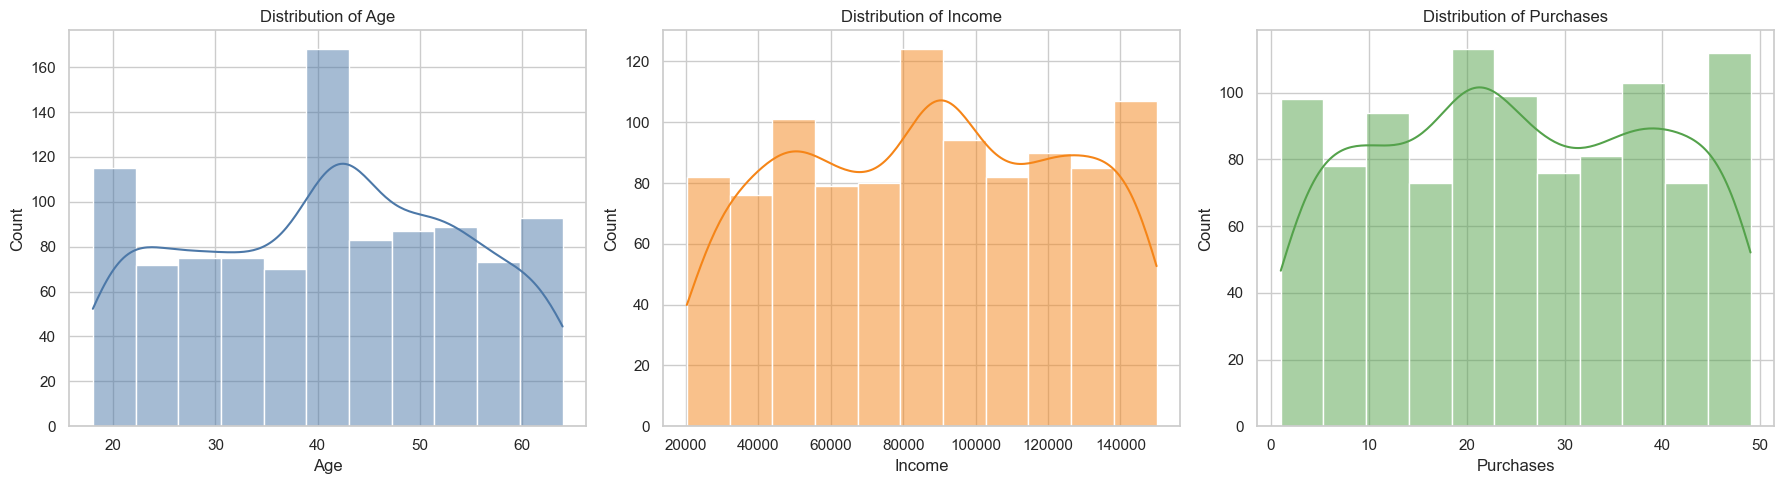

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean['Age'], kde=True, ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribution of Age')

sns.histplot(df_clean['Income'], kde=True, ax=axes[1], color='#F58518')
axes[1].set_title('Distribution of Income')

sns.histplot(df_clean['Purchases'], kde=True, ax=axes[2], color='#54A24B')
axes[2].set_title('Distribution of Purchases')

plt.tight_layout()
plt.show()

### D2. Bivariate Analysis

**Intuition:** Here we compare two variables at once. This helps answer business-style questions such as whether purchasing behavior differs by gender and whether higher income groups show different churn patterns.

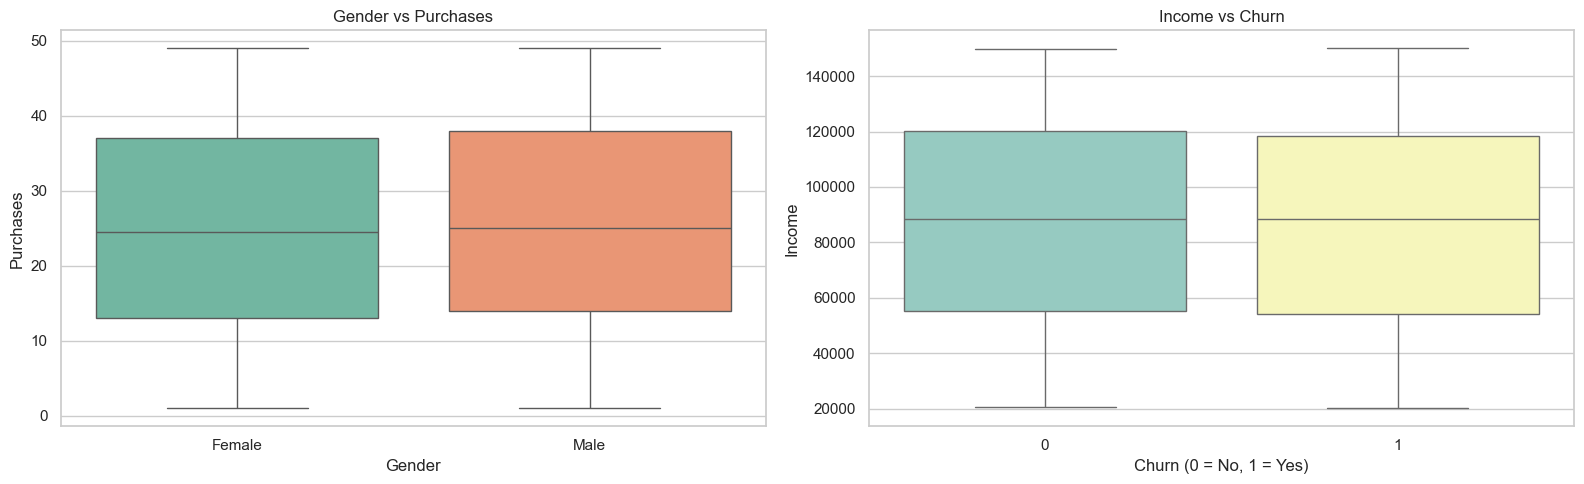

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df_clean, x='Gender', y='Purchases', hue='Gender', dodge=False, ax=axes[0], palette='Set2')
axes[0].set_title('Gender vs Purchases')
legend_0 = axes[0].get_legend()
if legend_0 is not None:
    legend_0.remove()

sns.boxplot(data=df_clean, x='Churn', y='Income', hue='Churn', dodge=False, ax=axes[1], palette='Set3')
axes[1].set_title('Income vs Churn')
axes[1].set_xlabel('Churn (0 = No, 1 = Yes)')
legend_1 = axes[1].get_legend()
if legend_1 is not None:
    legend_1.remove()

plt.tight_layout()
plt.show()

### D3. Multivariate Analysis

**Intuition:** Correlation heatmaps help identify numeric variables that move together, while pair plots show combinations of variables in a compact visual form. This is useful for spotting broader interaction patterns in the data.

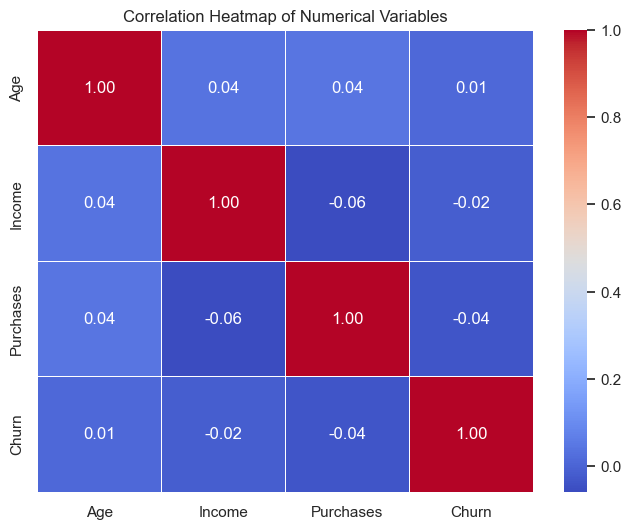

In [73]:
numeric_df = df_clean.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

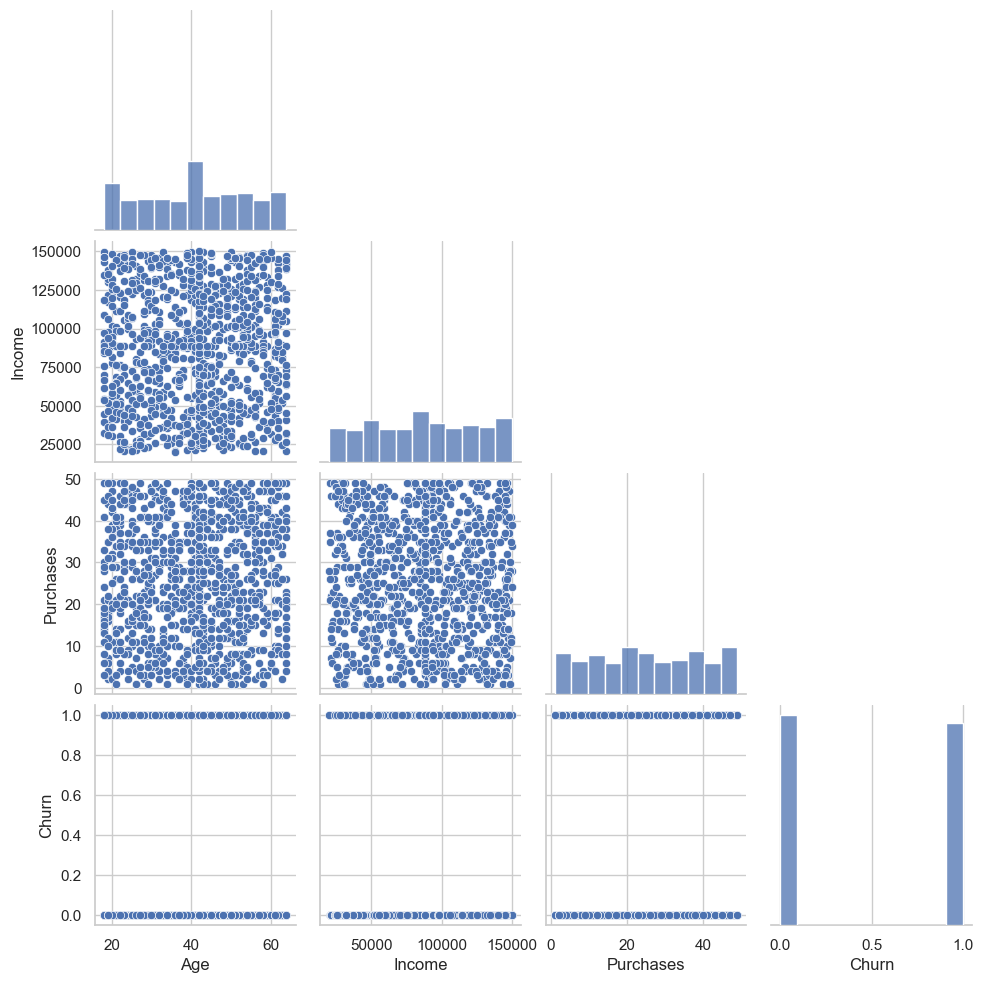

In [74]:
pairplot_columns = ['Age', 'Income', 'Purchases', 'Churn']
sns.pairplot(df_clean[pairplot_columns], corner=True, diag_kind='hist')
plt.show()

### D4. Short EDA Observations

**Intuition:** After visual exploration, it is good practice to write a few observations. This turns charts into findings that can support decisions.

In [75]:
observations = [
    f"The cleaned dataset contains {df_clean.shape[0]} rows and {df_clean.shape[1]} analysis-ready columns.",
    f"Median age is {df_clean['Age'].median():.1f} years.",
    f"Median income is {df_clean['Income'].median():,.0f}.",
    f"Average purchases are {df_clean['Purchases'].mean():.2f}.",
    f"Churn rate is {df_clean['Churn'].mean() * 100:.2f}% of customers."
]

for item in observations:
    print('-', item)

- The cleaned dataset contains 1000 rows and 6 analysis-ready columns.
- Median age is 42.0 years.
- Median income is 88,482.
- Average purchases are 25.27.
- Churn rate is 49.10% of customers.


## Part E: Data Profiling

**Intuition:** Data profiling tools automate dataset inspection by summarizing statistics, missing values, correlations, and potential data quality issues in one place. This is useful when we want a fast but comprehensive overview of the dataset.

### E1. Generate a Pandas Profiling-Style Report

**Intuition:** The preferred approach is to use `ydata-profiling` (the modern version of Pandas Profiling). If that package is unavailable in the environment, the notebook falls back to a manual profiling summary so the cell still runs without errors.

In [76]:
profile_output = base_path / 'data_profile_report.html'

try:
    from ydata_profiling import ProfileReport

    profile = ProfileReport(df_clean, title='Customer Data Profiling Report', explorative=True)
    profile.to_file(profile_output)
    print(f'Profiling report generated successfully: {profile_output}')
    display(HTML(f"<a href='data_profile_report.html' target='_blank'>Open the HTML profiling report</a>"))
except Exception as exc:
    print('ydata_profiling is not available, so a manual profiling summary is shown instead.')
    print(f'Reason: {exc}')

    descriptive_stats = df_clean.describe(include='all').transpose()
    correlations = df_clean.select_dtypes(include=[np.number]).corr()
    warnings_list = [
        'Original dataset contained missing values in Age and Income.',
        'Original dataset contained duplicate rows.',
        'CustomerID was dropped because it is an identifier and not analytically useful.'
    ]

    html_report = f"""
    <html>
    <head><title>Customer Data Profiling Report</title></head>
    <body style='font-family: Arial, sans-serif; margin: 24px;'>
        <h1>Customer Data Profiling Report</h1>
        <h2>Dataset Shape</h2>
        <p>{df_clean.shape}</p>
        <h2>Missing Values</h2>
        {df_clean.isna().sum().to_frame(name='Missing Values').to_html()}
        <h2>Descriptive Statistics</h2>
        {descriptive_stats.to_html()}
        <h2>Correlations</h2>
        {correlations.to_html()}
        <h2>Warnings</h2>
        <ul>{''.join(f'<li>{warning}</li>' for warning in warnings_list)}</ul>
    </body>
    </html>
    """

    profile_output.write_text(html_report, encoding='utf-8')
    print(f'Manual HTML profiling report generated: {profile_output}')
    display(HTML(f"<a href='data_profile_report.html' target='_blank'>Open the generated HTML report</a>"))

    print('Warnings:')
    for warning in warnings_list:
        print('-', warning)

    display(descriptive_stats)
    display(correlations)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 313.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling report generated successfully: d:\All Data\Data Profiler\data_profile_report.html


## Final Outcome

This notebook now demonstrates:
- Loading data from **CSV, JSON, SQL, and API** sources.
- Performing **data exploration** using `head()`, `info()`, and `describe()`.
- Handling **missing values**, **duplicates**, and **irrelevant columns**.
- Creating **univariate**, **bivariate**, and **multivariate** visualizations.
- Building an automated **profiling report** or a safe manual fallback when the profiling library is unavailable.
